# Set-up

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from CIBUSmod.impact.LULUC import LUCTimeSeries, LUParcel1, LUParcel2

In [4]:
LUParcel1?

Init signature: LUParcel1(t0: int, A0: float, C0: dict, pars: dict)
Docstring:     
Class to keep track of areas and carbon stocks in land use parcels. Carbon stocks
are assumed to change over time according to a first-order growth/decay function
given by:

Ct+1 = Ct + α(Cmax - Ct), where
α = 1 - exp(-ln(2)/T50),

Ct is the carbon stock (kg C/ha) at year t, Cmax is the maximum carbon stock,
and T50 is the number of years it takes to reach exactly half way from Ct to Cmax
(i.e. the half-time).

Parameters
----------
t0 : int
    Start year for land use parcel [year]
A0 : float
    Area of land use parcel at time t=(t0-1) [ha]
C0 : dict(
    C : float
        Carbon stock at t=(t0-1) [kg C / ha]
)
pars : dict(
    Cmax : float
        Maximum carbon stock in land use parcel [kg C/ha]
    T50 : float
        Half-time for first-order growth/decay function [years]
)
File:           c:\users\jnka0003\git repos\cibusmod\cibusmod\impact\luluc.py
Type:           type
Subclasses:     

In [5]:
LUParcel2?

Init signature: LUParcel2(t0: int, A0: float, C0: dict, pars: dict)
Docstring:     
Class to keep track of areas and carbon stocks in a land use parcel. Carbon stocks
are modelled with the simple forest carbon cycle model presented by Harmon (2001). The
model consists of three carbon pools: live biomass (LC), detritus (DC) and soil (SC).

CL(t+1) = Lmax*(1 - (1 - (CL(t)/Lmax)^(1/B2)) * np.exp(-B1))^B2
CD(t+1) = CD(t)*(1 - k - sf) + CL(t)*m
CS(t+1) = CS(t)*(1 - sk) + CD(t)*sf

The equation for CL has been reformulated from the one presented by Harmon (2001) to express CL(t+1) as a function
of CL(t) instead of t.

Mark E. Harmon. 2001. Carbon cycling in forests: simple simulation models. H. J. Andrews Research Report Number 2.
https://andrewsforest.oregonstate.edu/sites/default/files/lter/pubs/webdocs/reports/ccycleforest/ccycleforest.pdf 
https://andrewsforest.oregonstate.edu/sites/default/files/lter/pubs/webdocs/reports/~1st-ccycleforest2.htm 

Parameters
----------
t0 : int
    Start 

## Define paramters for LUC calculations
These are not grounded in anything but only to test. But, maybee they are sort of in a correct order of magnitude.

In [6]:
extend = 50 # years

# For LUCTimeSeries -------------------------->
LU_pars1 = {
    'forest, mineral' : {
        'Cmax' : 100_000,
        'T50' : 20
    },
    'cropland, mineral' : {
        'Cmax' : 2_000,
        'T50' : 0.5
    },
}
LUC_pars1 = {
    'cropland, mineral soil' : {
        'target_lu_pars' : LU_pars1['cropland, mineral'],
        'alt_lu_pars' : LU_pars1['forest, mineral'],
        'parcel_class' : LUParcel1
    },
    'semi-natural grasslands, mineral soil' : {
        'target_lu_pars' : LU_pars1['cropland, mineral'],
        'alt_lu_pars' : LU_pars1['forest, mineral'],
        'parcel_class' : LUParcel1
    },
    'cropland, organic soil' : {
        'target_lu_pars' : LU_pars1['cropland, mineral'],
        'alt_lu_pars' : LU_pars1['forest, mineral'],
        'parcel_class' : LUParcel1
    },
    'semi-natural grasslands, organic soil' : {
        'target_lu_pars' : LU_pars1['cropland, mineral'],
        'alt_lu_pars' : LU_pars1['forest, mineral'],
        'parcel_class' : LUParcel1
    }
}

# For LUCTimeSeries2 ------------------------>
LU_pars2 = {
    'forest, default' : {
        'Lmax' : 100_000,
        'B1' : 0.02,
        'B2' : 2,
        'm' : 0.01,
        'k' : 0.05,
        'sf' : 0.02,
        'sk' : 0.01
    },
    'forest, mineral' : {
        'Lmax' : 100_000,
        'B1' : 0.02,
        'B2' : 2,
        'm' : 0.01,
        'k' : 0.05,
        'sf' : 0.05,
        'sk' : 0.01
    },
    'cropland, mineral' : {
        'Lmax' : 2_500,
        'B1' : 4,
        'B2' : 1,
        'm' : 1,
        'k' : 0.2,
        'sf' : 0.8,
        'sk' : 0.04
    },
}
LUC_pars2 = {
    'cropland, mineral soil' : {
        'target_lu_pars' : LU_pars2['cropland, mineral'],
        'alt_lu_pars' : LU_pars2['forest, mineral'],
        'parcel_class' : LUParcel2
    },
    'semi-natural grasslands, mineral soil' : {
        'target_lu_pars' : LU_pars2['cropland, mineral'],
        'alt_lu_pars' : LU_pars2['forest, mineral'],
        'parcel_class' : LUParcel2
    },
    'cropland, organic soil' : {
        'target_lu_pars' : LU_pars2['cropland, mineral'],
        'alt_lu_pars' : LU_pars2['forest, mineral'],
        'parcel_class' : LUParcel2
    },
    'semi-natural grasslands, organic soil' : {
        'target_lu_pars' : LU_pars2['cropland, mineral'],
        'alt_lu_pars' : LU_pars2['forest, mineral'],
        'parcel_class' : LUParcel2
    }
}


# LUC calculations for constructed time-series

## Create three different LU trajectories

In [18]:
np.concatenate([np.zeros(10),np.ones(21)]).shape

(31,)

In [19]:
range(2020,2050+1)

range(2020, 2051)

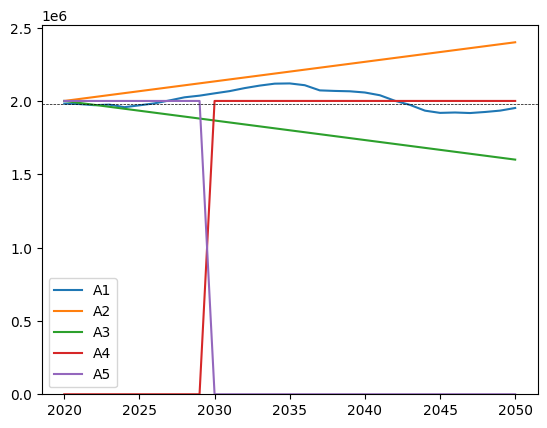

In [23]:
import matplotlib.pyplot as plt

# Generate land use time series
A = {}
A0 = 2_000_000
At = A0
for t in range(2020,2050+1):
    Ach = -np.sin(t/4)*(A0/100) + np.random.randn()*(A0/100/2)
    At += Ach
    A.update({t:At})
    
A1 = pd.Series(A)
A2 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*1.2,31))})
A3 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*0.8,31))})

A4 = pd.Series(np.concatenate([np.zeros(10),np.ones(21)])*A0, index = range(2020,2050+1))
A5 = pd.Series(np.concatenate([np.ones(10),np.zeros(21)])*A0, index = range(2020,2050+1))

ax = A1.plot(label='A1')
A2.plot(ax=ax, label='A2')
A3.plot(ax=ax, label='A3')
A4.plot(ax=ax, label='A4')
A5.plot(ax=ax, label='A5')
ax.axhline(A1.iloc[0], color='black', linestyle='--',linewidth=0.5)
ax.set_ylim(0)
ax.legend()
plt.show()

In [36]:
# Select time-series
Ach = A4.diff().fillna(0)

## Model with `LUParcel1`

<Axes: xlabel='year'>

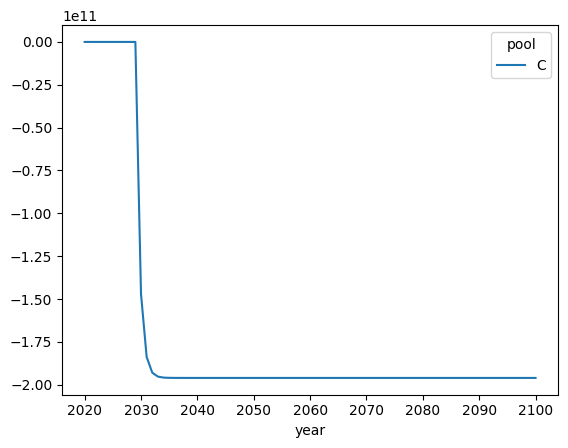

In [37]:
LUCts = LUCTimeSeries(
    Ach = Ach,
    **LUC_pars1['cropland, mineral soil'],
    extend = extend
)
LUCts.calculate_parcels()
LUCts.get_stocks().plot()

## Model with `LUParcel2`

<Axes: xlabel='year'>

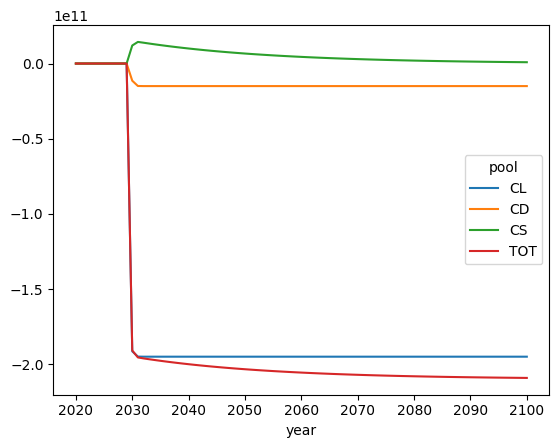

In [38]:
LUCts = LUCTimeSeries(
    Ach = Ach,
    **LUC_pars2['cropland, mineral soil'],
    extend = extend
)
LUCts.calculate_parcels()
d = LUCts.get_stocks()
d['TOT'] = d.sum(axis=1)
d.plot()

# LUC for scenarios

## Initiate Session

In [39]:
# MFF scenarios
session = cm.Session(
    name = 'MFF',
    data_path = '../data',
    data_path_output = '../../MFF-scenarios/output'
)

In [40]:
# Base20 and Sust50
# session = cm.Session(
#     name = 'example_scenarios',
#     data_path = '../data'
# )

## Get GHG emissions from model output and calculate temperature response

In [41]:
%%time
ghg = (
    cm.impact.get_GHG(session, CO2eq=None, interpolate=True)
    .rename(lambda x: 'CH4' if 'CH4' in x else ('N2O' if 'N2O' in x else x), axis=1)
    .T.groupby('compound').sum().T
)
dT_GHG = cm.impact.get_deltaT(ghg, extend=50) * 1_000

Getting GHG emissions ...
Calculating temperature response ...
CPU times: total: 56.5 s
Wall time: 1min 4s


## Get land use

In [42]:
# Get land use
lu_df = session.get_attr('C','area',{'crop':'land_use','region':None}, interpolate=True).drop('greenhouse', axis=1)
lu_org = session.get_attr('C', 'organic_soil_area', {'crop':'land_use','region':None}, interpolate=True)
# Separate organic and mineral soils
lu_min = lu_df - lu_org
lu_min = lu_min.rename({
    'cropland' : 'cropland, mineral soil',
    'semi-natural grasslands' : 'semi-natural grasslands, mineral soil'
}, axis=1)
lu_org = lu_org.rename({
    'cropland' : 'cropland, organic soil',
    'semi-natural grasslands' : 'semi-natural grasslands, organic soil'
}, axis=1)
# Combine
lu_df = pd.concat([lu_min,lu_org], axis=1)

## Calculate LUC
Calculations are done with:
- `LUParcel1` (simple first-order growth/decay function)
- `LUParcel2` (simple forest C model w. 3 C-pools; Harmon 2001)

Mark E. Harmon. 2001. Carbon cycling in forests: simple simulation models. H. J. Andrews Research Report Number 2.    
https://andrewsforest.oregonstate.edu/sites/default/files/lter/pubs/webdocs/reports/ccycleforest/ccycleforest.pdf    
https://andrewsforest.oregonstate.edu/sites/default/files/lter/pubs/webdocs/reports/~1st-ccycleforest2.htm

### Create data frames with `LUCTimeSeries` objects
One `LUCTimeSeries` is created per each of the four land use categories and for each region and use the parameters defined above. Then the time-series are calculated and stored in the **LUC_df** data frames.

In [43]:
%%time
LUC_dfs = []
for LUC_pars in [LUC_pars1, LUC_pars2]:
    print(LUC_pars)
    LUC_df = pd.DataFrame(
        index = lu_df.index.unique('scn'),
        columns = lu_df.columns
    )
    for scn in LUC_df.index:
        for lu,re in LUC_df.columns:
            Ach = lu_df.loc[scn,(lu,re)].diff().fillna(0)
            LUCts = LUCTimeSeries(
                Ach = Ach,
                **LUC_pars[lu],
                extend = extend
            )
            LUCts.calculate_parcels()
            LUC_df.loc[scn,(lu,re)] = LUCts
    LUC_dfs += [LUC_df]

{'cropland, mineral soil': {'target_lu_pars': {'Cmax': 2000, 'T50': 0.5}, 'alt_lu_pars': {'Cmax': 100000, 'T50': 20}, 'parcel_class': <class 'CIBUSmod.impact.LULUC.LUParcel1'>}, 'semi-natural grasslands, mineral soil': {'target_lu_pars': {'Cmax': 2000, 'T50': 0.5}, 'alt_lu_pars': {'Cmax': 100000, 'T50': 20}, 'parcel_class': <class 'CIBUSmod.impact.LULUC.LUParcel1'>}, 'cropland, organic soil': {'target_lu_pars': {'Cmax': 2000, 'T50': 0.5}, 'alt_lu_pars': {'Cmax': 100000, 'T50': 20}, 'parcel_class': <class 'CIBUSmod.impact.LULUC.LUParcel1'>}, 'semi-natural grasslands, organic soil': {'target_lu_pars': {'Cmax': 2000, 'T50': 0.5}, 'alt_lu_pars': {'Cmax': 100000, 'T50': 20}, 'parcel_class': <class 'CIBUSmod.impact.LULUC.LUParcel1'>}}
{'cropland, mineral soil': {'target_lu_pars': {'Lmax': 2500, 'B1': 4, 'B2': 1, 'm': 1, 'k': 0.2, 'sf': 0.8, 'sk': 0.04}, 'alt_lu_pars': {'Lmax': 100000, 'B1': 0.02, 'B2': 2, 'm': 0.01, 'k': 0.05, 'sf': 0.05, 'sk': 0.01}, 'parcel_class': <class 'CIBUSmod.impact.

### Get CO2 emissions from `LUCTimeSeries` and calculate temperature response
Emissions are here aggregated over all C pools, land use categories and regions.

In [44]:
%%time
dT_LUCs = []
for LUC_df in LUC_dfs:
    LUC_CO2 = pd.DataFrame(
        index = dT_GHG.index,
        columns = pd.Index(['CO2'], name='compound'),
    )
    for scn in ghg.index.unique('scn'):
        res = pd.Series(0, index = dT_GHG.index.unique('year'), name='CO2')
        for LUCts in LUC_df.loc[scn]:
            r = LUCts.get_CO2().sum(axis=1)
            r.index = r.index.astype(str)
            res += r
        LUC_CO2.loc[scn,'CO2'] = res.values
    dT_LUC = cm.impact.get_deltaT(LUC_CO2).rename({'CO2':'CO2 (LUC)'}, axis=1) * 1_000
    dT_LUCs += [dT_LUC]

Getting GHG emissions ...
Calculating temperature response ...
Getting GHG emissions ...
Calculating temperature response ...
CPU times: total: 26.3 s
Wall time: 26.3 s


## Combine temperature responses from GHG emissions and LUC CO2

In [45]:
dT1 = pd.concat([dT_GHG,dT_LUCs[0]], axis=1)
dT1['TOT'] = dT1.sum(axis=1)

dT2 = pd.concat([dT_GHG,dT_LUCs[1]], axis=1)
dT2['TOT'] = dT2.sum(axis=1)

## Plot results

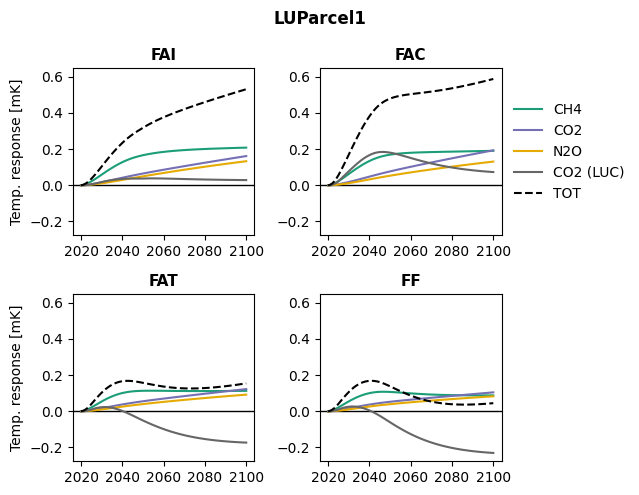

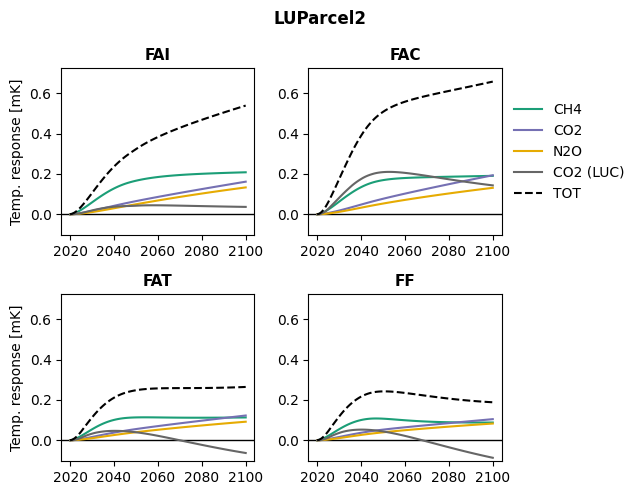

In [46]:
for t,df in zip(['LUParcel1','LUParcel2'],[dT1,dT2]):
    fig,axs = plt.subplots(2,2, figsize=(6.5,5))
    for ax,scn in zip(axs.flatten(),df.index.unique('scn')):
        ax.axhline(0, color='black', linewidth=1)
        df.loc[scn].iloc[:,:-1].plot(ax=ax, cmap='Dark2', legend=False)
        df.loc[scn].iloc[:,[-1]].plot(ax=ax, linestyle='--', color='black', legend=False)
        ax.set_ylim(df.min().min()*1.2, df.max().max()*1.1)
        ax.set_title(scn, size=11, fontweight='bold')
        if ax in axs.T[0]:
            ax.set_ylabel('Temp. response [mK]')
        ax.set_xlabel('')
        if ax == axs[0][1]:
            ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
    
    fig.suptitle(t, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test `LUParcel` objects

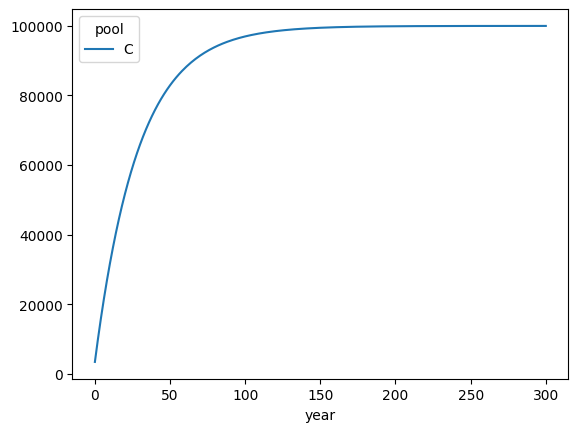

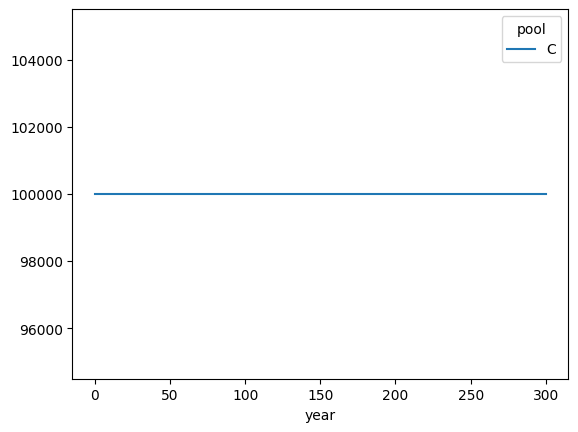

In [47]:
a=LUParcel1(
    t0 = 0,
    A0 = 1,
    C0 = {'C':0},
    pars = {'Cmax':100_000, 'T50':20}
)

for i in range(301):
    a.time_step()
a.stock_time_series().plot()
plt.show()
a.spin_up()
for i in range(301):
    a.time_step()
a.stock_time_series().plot()
plt.show()

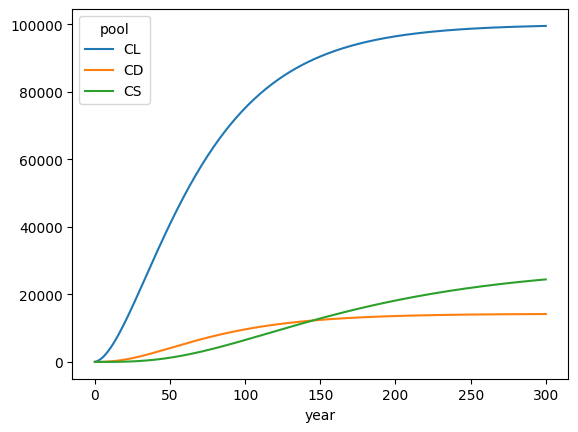

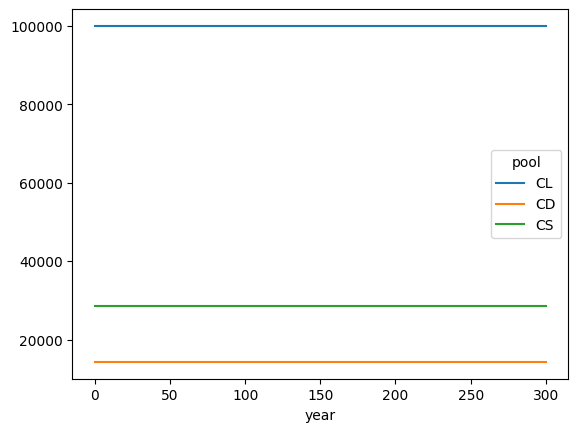

In [48]:
a=LUParcel2(
    t0 = 0,
    A0 = 1,
    C0 = {'CL':0,'CD':0,'CS':0},
    pars = {
        'Lmax' : 100_000,
        'B1' : 0.02,
        'B2' : 2,
        'm' : 0.01,
        'k' : 0.05,
        'sf' : 0.02,
        'sk' : 0.01
    }
)

for i in range(301):
    a.time_step()
a.stock_time_series().plot()
plt.show()
a.spin_up()
for i in range(301):
    a.time_step()
a.stock_time_series().plot()
plt.show()